In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
zip_path = '/content/drive/MyDrive/FruitinAmazon.zip'
extract_dir = '/content/FruitinAmazon'

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Extracted to {extract_dir}")
else:
    print(f"{extract_dir} already exists, skipping extraction.")

train_dir = os.path.join(extract_dir, 'FruitinAmazon', 'train')
test_dir = os.path.join(extract_dir, 'FruitinAmazon', 'test')

class_names = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])
NUM_CLASSES = len(class_names)

if not class_names:
    raise RuntimeError('No class directories found in the train folder.')

def count_images(directory):
    total = 0
    for cls in os.listdir(directory):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            total += len([f for f in os.listdir(cls_path)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    return total

print(f"Classes ({NUM_CLASSES}): {class_names}")
print(f"Train images: {count_images(train_dir)}")
print(f"Test images: {count_images(test_dir)}")

/content/FruitinAmazon already exists, skipping extraction.
Classes (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Train images: 90
Test images: 30


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Train batches: {len(train_gen)}")
print(f"Validation batches: {len(val_gen)}")
print(f"Test batches: {len(test_gen)}")

Found 78 images belonging to 6 classes.
Found 12 images belonging to 6 classes.
Found 30 images belonging to 6 classes.
Train batches: 3
Validation batches: 1
Test batches: 1


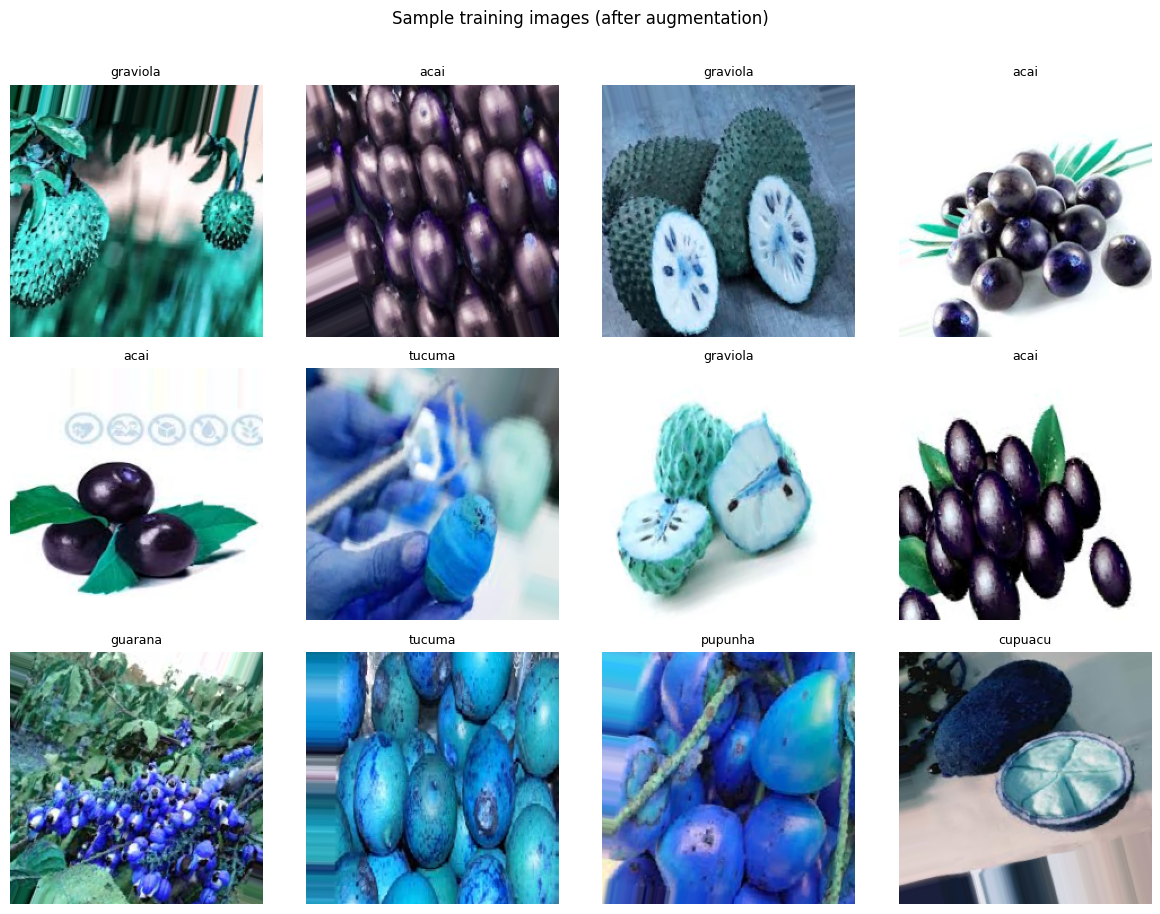

In [ ]:
def show_sample_grid(generator, class_names, n=12):
    images, labels = next(generator)
    disp = images.copy()
    disp += [103.939, 116.779, 123.68]  # reverse VGG16 preprocessing
    disp = np.clip(disp / 255.0, 0, 1)

    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    for i, ax in enumerate(axes.flat):
        if i >= n:
            break
        ax.imshow(disp[i])
        ax.set_title(class_names[np.argmax(labels[i])], fontsize=9)
        ax.axis('off')
    plt.suptitle('Sample training images (after augmentation)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

show_sample_grid(train_gen, class_names)

## Phase 1 — Feature Extraction

All VGG16 convolutional layers are frozen. Only the classification head is trained.

In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

feature_model = Model(inputs, outputs, name='VGG16_FeatureExtraction')
feature_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
feature_model.summary()

Model: "VGG16_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,113,286 (57.65 MB)

 Trainable params: 397,062 (1.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [ ]:
EPOCHS_PHASE1 = 50

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_feature_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_phase1 = feature_model.fit(
    train_gen,
    epochs=EPOCHS_PHASE1,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    verbose=1
)

loss_p1, acc_p1 = feature_model.evaluate(test_gen, verbose=0)
print(f"Phase 1 — Test Loss: {loss_p1:.4f}, Test Accuracy: {acc_p1*100:.2f}%")

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2632 - loss: 2.2962
Epoch 1: val_accuracy improved from None to 0.41667, saving model to best_feature_model.h5



Epoch 1: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.2692 - loss: 2.2542 - val_accuracy: 0.4167 - val_loss: 1.9665 - learning_rate: 0.0010
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.6517 - loss: 1.1067
Epoch 2: val_accuracy improved from 0.41667 to 0.75000, saving model to best_feature_model.h5



Epoch 2: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 647ms/step - accuracy: 0.6538 - loss: 1.0414 - val_accuracy: 0.7500 - val_loss: 0.7783 - learning_rate: 0.0010
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.7769 - loss: 0.5580
Epoch 3: val_accuracy improved from 0.75000 to 0.83333, saving model to best_feature_model.h5



Epoch 3: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 748ms/step - accuracy: 0.8077 - loss: 0.5256 - val_accuracy: 0.8333 - val_loss: 0.3796 - learning_rate: 0.0010
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.8043 - loss: 0.5127
Epoch 4: val_accuracy improved from 0.83333 to 0.91667, saving model to best_feature_model.h5



Epoch 4: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 908ms/step - accuracy: 0.7949 - loss: 0.4668 - val_accuracy: 0.9167 - val_loss: 0.1692 - learning_rate: 0.0010
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.9128 - loss: 0.2344
Epoch 5: val_accuracy improved from 0.91667 to 1.00000, saving model to best_feature_model.h5



Epoch 5: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 480ms/step - accuracy: 0.9103 - loss: 0.2320 - val_accuracy: 1.0000 - val_loss: 0.0713 - learning_rate: 0.0010
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.9519 - loss: 0.2359
Epoch 6: val_accuracy did not improve from 1.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 399ms/step - accuracy: 0.9615 - loss: 0.2005 - val_accuracy: 0.9167 - val_loss: 0.0839 - learning_rate: 0.0010
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9539 - loss: 0.1556
Epoch 7: val_accuracy did not improve from 1.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step - accuracy: 0.9487 - loss: 0.1910 - val_accuracy: 1.0000 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 5.
Phase 1 — Test Loss: 0.1898, Test Accuracy: 93.33%


## Phase 2 — Fine-Tuning

The last two layers of VGG16 (block5) are unfrozen and the full model is retrained with a lower learning rate.

In [ ]:
base_model_ft = VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))

FINE_TUNE_AT = len(base_model_ft.layers) - 2
for layer in base_model_ft.layers[:FINE_TUNE_AT]:
    layer.trainable = False
for layer in base_model_ft.layers[FINE_TUNE_AT:]:
    layer.trainable = True

print(f"Unfrozen layers: {[l.name for l in base_model_ft.layers if l.trainable]}")

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model_ft(inputs, training=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

finetune_model = Model(inputs, outputs, name='VGG16_FineTuning')

for layer in finetune_model.layers:
    for feat_layer in feature_model.layers:
        if layer.name == feat_layer.name and layer.name != 'vgg16':
            try:
                layer.set_weights(feat_layer.get_weights())
            except:
                pass

finetune_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable_params = sum([tf.size(w).numpy() for w in finetune_model.trainable_weights])
print(f"Total params: {finetune_model.count_params():,}")
print(f"Trainable params: {trainable_params:,}")
finetune_model.summary()

Unfrozen layers: ['block5_conv3', 'block5_pool']
Total params: 14,879,686
Trainable params: 2,524,806


Model: "VGG16_FineTuning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,686 (56.76 MB)

 Trainable params: 2,524,806 (9.63 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

In [ ]:
EPOCHS_PHASE2 = 100

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_finetune_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_phase2 = finetune_model.fit(
    train_gen,
    epochs=EPOCHS_PHASE2,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    verbose=1
)

loss_p2, acc_p2 = finetune_model.evaluate(test_gen, verbose=0)
print(f"Phase 2 — Test Loss: {loss_p2:.4f}, Test Accuracy: {acc_p2*100:.2f}%")
print(f"Improvement: +{(acc_p2 - acc_p1)*100:.2f}%")

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1201 - loss: 5.3447
Epoch 1: val_accuracy improved from None to 0.50000, saving model to best_finetune_model.h5



Epoch 1: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.1795 - loss: 4.3361 - val_accuracy: 0.5000 - val_loss: 2.4065 - learning_rate: 1.0000e-04
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.3782 - loss: 2.2878
Epoch 2: val_accuracy did not improve from 0.50000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step - accuracy: 0.4359 - loss: 1.9532 - val_accuracy: 0.3333 - val_loss: 1.6959 - learning_rate: 1.0000e-04
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.7494 - loss: 0.9038
Epoch 3: val_accuracy improved from 0.50000 to 0.58333, saving model to best_finetune_model.h5



Epoch 3: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 638ms/step - accuracy: 0.7949 - loss: 0.6608 - val_accuracy: 0.5833 - val_loss: 0.8724 - learning_rate: 1.0000e-04
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.8125 - loss: 0.4778
Epoch 4: val_accuracy improved from 0.58333 to 0.75000, saving model to best_finetune_model.h5



Epoch 4: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 0.8205 - loss: 0.4478 - val_accuracy: 0.7500 - val_loss: 0.9339 - learning_rate: 1.0000e-04
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9433 - loss: 0.1637
Epoch 5: val_accuracy improved from 0.75000 to 0.83333, saving model to best_finetune_model.h5



Epoch 5: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 0.9359 - loss: 0.1869 - val_accuracy: 0.8333 - val_loss: 0.4532 - learning_rate: 1.0000e-04
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.9519 - loss: 0.1483
Epoch 6: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 397ms/step - accuracy: 0.9615 - loss: 0.1601 - val_accuracy: 0.8333 - val_loss: 0.3930 - learning_rate: 1.0000e-04
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.9885 - loss: 0.1036
Epoch 7: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 400ms/step - accuracy: 0.9872 - loss: 0.0793 - val_accuracy: 0.8333 - val_loss: 0.3760 - learning_rate: 1.0000e-04
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 1.0000 - loss: 0.0540
Epoch 8: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 698ms/step - accuracy: 1.0000 - loss: 0.0348 - val_accuracy: 0.6667 - val_los

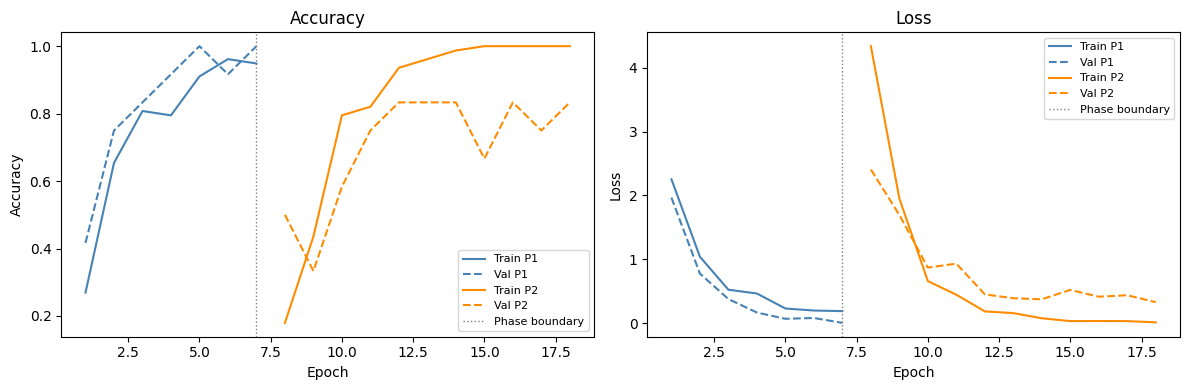

In [ ]:
def plot_training_history(h1, h2):
    ep1 = range(1, len(h1.history['accuracy']) + 1)
    ep2 = range(len(ep1) + 1, len(ep1) + len(h2.history['accuracy']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(ep1, h1.history['accuracy'], color='steelblue', label='Train P1')
    axes[0].plot(ep1, h1.history['val_accuracy'], color='steelblue', linestyle='--', label='Val P1')
    axes[0].plot(ep2, h2.history['accuracy'], color='darkorange', label='Train P2')
    axes[0].plot(ep2, h2.history['val_accuracy'], color='darkorange', linestyle='--', label='Val P2')
    axes[0].axvline(x=len(ep1), color='gray', linestyle=':', linewidth=1, label='Phase boundary')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Accuracy')
    axes[0].legend(fontsize=8)

    axes[1].plot(ep1, h1.history['loss'], color='steelblue', label='Train P1')
    axes[1].plot(ep1, h1.history['val_loss'], color='steelblue', linestyle='--', label='Val P1')
    axes[1].plot(ep2, h2.history['loss'], color='darkorange', label='Train P2')
    axes[1].plot(ep2, h2.history['val_loss'], color='darkorange', linestyle='--', label='Val P2')
    axes[1].axvline(x=len(ep1), color='gray', linestyle=':', linewidth=1, label='Phase boundary')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Loss')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

plot_training_history(history_phase1, history_phase2)

In [ ]:
test_gen.reset()
y_pred_prob = finetune_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step
              precision    recall  f1-score   support

        acai     0.5714    0.8000    0.6667         5
     cupuacu     0.6667    0.4000    0.5000         5
    graviola     0.8333    1.0000    0.9091         5
     guarana     0.8000    0.8000    0.8000         5
     pupunha     0.3333    0.2000    0.2500         5
      tucuma     0.5000    0.6000    0.5455         5

    accuracy                         0.6333        30
   macro avg     0.6175    0.6333    0.6119        30
weighted avg     0.6175    0.6333    0.6119        30



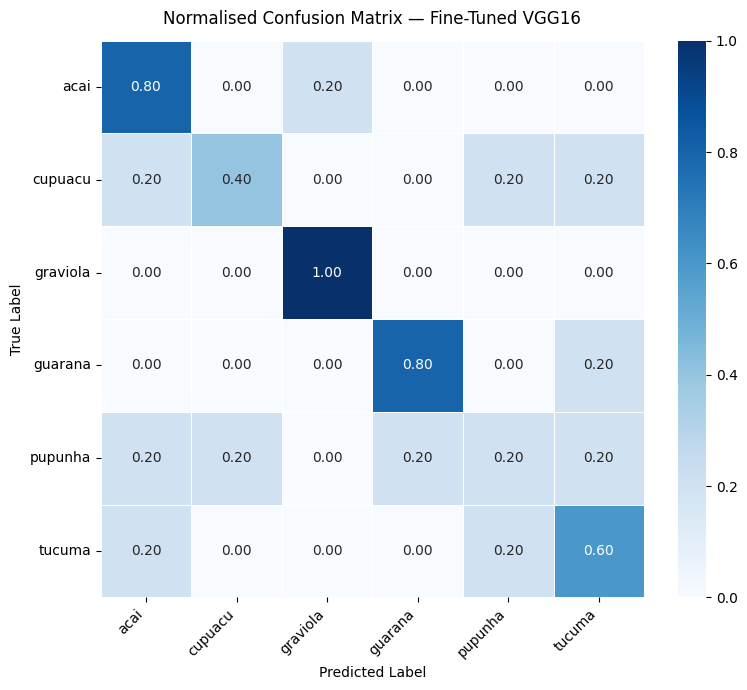

In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES), max(7, NUM_CLASSES - 1)))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues',
    linewidths=0.4,
    ax=ax
)
ax.set_title('Normalised Confusion Matrix — Fine-Tuned VGG16', pad=12)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

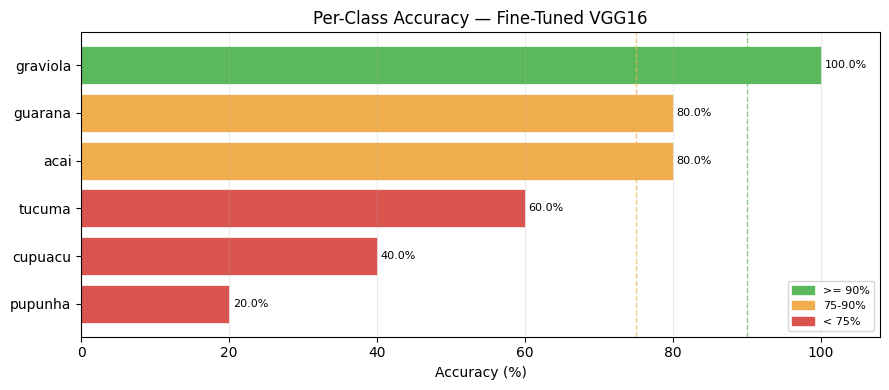

In [ ]:
per_class_acc = cm_norm.diagonal()

sorted_idx = np.argsort(per_class_acc)
sorted_classes = [class_names[i] for i in sorted_idx]
sorted_acc = per_class_acc[sorted_idx]

colors = ['#d9534f' if a < 0.75 else '#f0ad4e' if a < 0.90 else '#5cb85c' for a in sorted_acc]

fig, ax = plt.subplots(figsize=(9, max(4, NUM_CLASSES * 0.5)))
ax.barh(sorted_classes, sorted_acc * 100, color=colors, edgecolor='white', linewidth=0.5)

for i, val in enumerate(sorted_acc):
    ax.text(val * 100 + 0.5, i, f'{val*100:.1f}%', va='center', fontsize=8)

ax.axvline(x=90, color='#5cb85c', linestyle='--', alpha=0.7, linewidth=1)
ax.axvline(x=75, color='#f0ad4e', linestyle='--', alpha=0.7, linewidth=1)

legend_patches = [
    mpatches.Patch(color='#5cb85c', label='>= 90%'),
    mpatches.Patch(color='#f0ad4e', label='75-90%'),
    mpatches.Patch(color='#d9534f', label='< 75%'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)
ax.set_xlabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy — Fine-Tuned VGG16')
ax.set_xlim(0, 108)
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()